# **1. Import Libraries**

In [2]:
!pip install -q nltk wordcloud

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [4]:
# Download NLTK Resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# **2. Load Dataset**

In [5]:
from google.colab import files

uploaded = files.upload()

Saving Sentences_75Agree.txt to Sentences_75Agree.txt


In [6]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(
    file_name,
    sep='@',
    header=None,
    names=['text', 'sentiment'],
    encoding='latin-1'
)

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (3453, 2)

Column Names:
['text', 'sentiment']

First 5 Rows:


,text,sentiment
0,"According to Gran , the company has no plans t...",neutral
1,With the new production plant the company woul...,positive
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,"In the third quarter of 2010 , net sales incre...",positive
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3453 entries, 0 to 3452
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       3453 non-null   object
 1   sentiment  3453 non-null   object
dtypes: object(2)
memory usage: 54.1+ KB


In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
text         0
sentiment    0
dtype: int64


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5


In [10]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (3448, 2)


# **3. Check Sentiment Distribution**

In [11]:
print(df['sentiment'].value_counts())

sentiment
neutral     2141
positive     887
negative     420
Name: count, dtype: int64


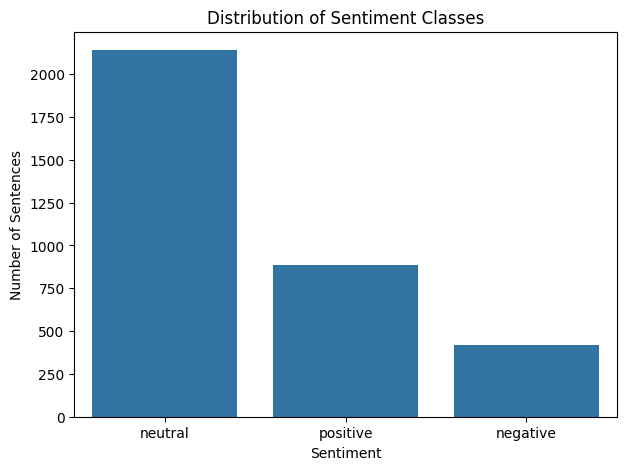

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='sentiment'
)

plt.title('Distribution of Sentiment Classes')
plt.xlabel('Sentiment')
plt.ylabel('Number of Sentences')

plt.show()

In [13]:
sentiment_percentage = (
    df['sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_percentage)

sentiment
neutral     62.09
positive    25.73
negative    12.18
Name: proportion, dtype: float64


# **4. Check Text Characteristics**

In [14]:
# Check test length
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

df['character_count'] = df['text'].apply(lambda x: len(str(x)))

df.head()

,text,sentiment,word_count,character_count
0,"According to Gran , the company has no plans t...",neutral,25,127
1,With the new production plant the company woul...,positive,33,206
2,"For the last quarter of 2010 , Componenta 's n...",positive,39,193
3,"In the third quarter of 2010 , net sales incre...",positive,29,125
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive,24,122


In [15]:
# Text Length Statistics
print(df[['word_count', 'character_count']].describe())

        word_count  character_count
count  3448.000000      3448.000000
mean     22.752030       124.813805
std      10.050943        56.310040
min       2.000000         9.000000
25%      15.000000        81.000000
50%      21.000000       116.000000
75%      29.000000       160.000000
max      81.000000       315.000000


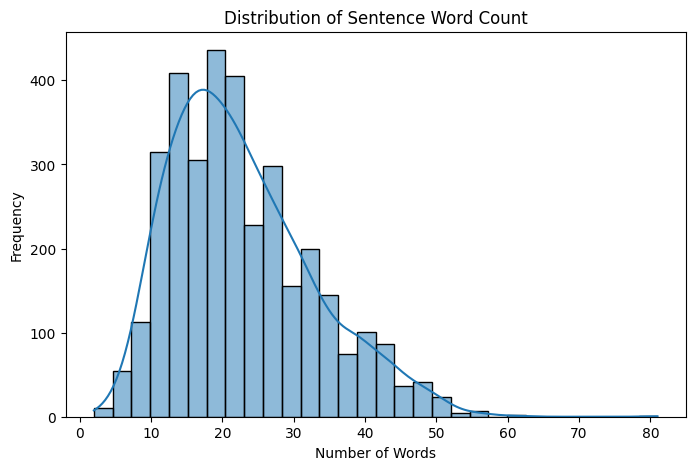

In [16]:
# Visualize Word Count
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='word_count',
    bins=30,
    kde=True
)

plt.title('Distribution of Sentence Word Count')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.show()


#**5. Text Preprocessing**

In [17]:
# Create Stopwords
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [18]:
# Create Cleaning Function

def clean_text(text):

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

In [19]:
# Apply Text Cleaning
df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text', 'sentiment']].head(10)

,text,clean_text,sentiment
0,"According to Gran , the company has no plans t...",according gran company plan move production ru...,neutral
1,With the new production plant the company woul...,new production plant company would increase ca...,positive
2,"For the last quarter of 2010 , Componenta 's n...",last quarter componenta net sale doubled eurm ...,positive
3,"In the third quarter of 2010 , net sales incre...",third quarter net sale increased eur mn operat...,positive
4,Operating profit rose to EUR 13.1 mn from EUR ...,operating profit rose eur mn eur mn correspond...,positive
5,"Operating profit totalled EUR 21.1 mn , up fro...",operating profit totalled eur mn eur mn repres...,positive
6,TeliaSonera TLSN said the offer is in line wit...,teliasonera tlsn said offer line strategy incr...,positive
7,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMEN...",stora enso norske skog mreal upmkymmene credit...,positive
8,"A purchase agreement for 7,200 tons of gasolin...",purchase agreement ton gasoline delivery hamin...,positive
9,Finnish Talentum reports its operating profit ...,finnish talentum report operating profit incre...,positive


In [20]:
# Check Empty Text

empty_text = (df['clean_text'].str.strip() == '').sum()

print("Empty cleaned texts:", empty_text)

df = df[df['clean_text'].str.strip() != '']

print("Dataset shape:", df.shape)

Empty cleaned texts: 1
Dataset shape: (3447, 5)


In [21]:
# Replace variations with standard terms
df['clean_text'] = df['clean_text'].str.replace(r'\b(mn|mln)\b', 'million', regex=True)
df['clean_text'] = df['clean_text'].str.replace(r'\b(eur)\b', 'euro', regex=True)

# 2. Remove location noise if you only want sentiment/business terms
custom_stopwords = {'finnish', 'finland', 'said'}
df['clean_text'] = df['clean_text'].apply(
    lambda text: ' '.join([word for word in text.split() if word not in custom_stopwords])
)

In [22]:
# Most Common Words

from collections import Counter

all_words = ' '.join(df['clean_text']).split()

word_frequency = Counter(all_words)

common_words = word_frequency.most_common(20)

common_words

[('euro', 1378),
 ('million', 1189),
 ('company', 640),
 ('sale', 405),
 ('profit', 388),
 ('net', 378),
 ('share', 355),
 ('year', 267),
 ('operating', 258),
 ('group', 237),
 ('period', 236),
 ('service', 220),
 ('quarter', 219),
 ('business', 199),
 ('market', 199),
 ('oyj', 168),
 ('new', 161),
 ('first', 159),
 ('also', 152),
 ('loss', 146)]

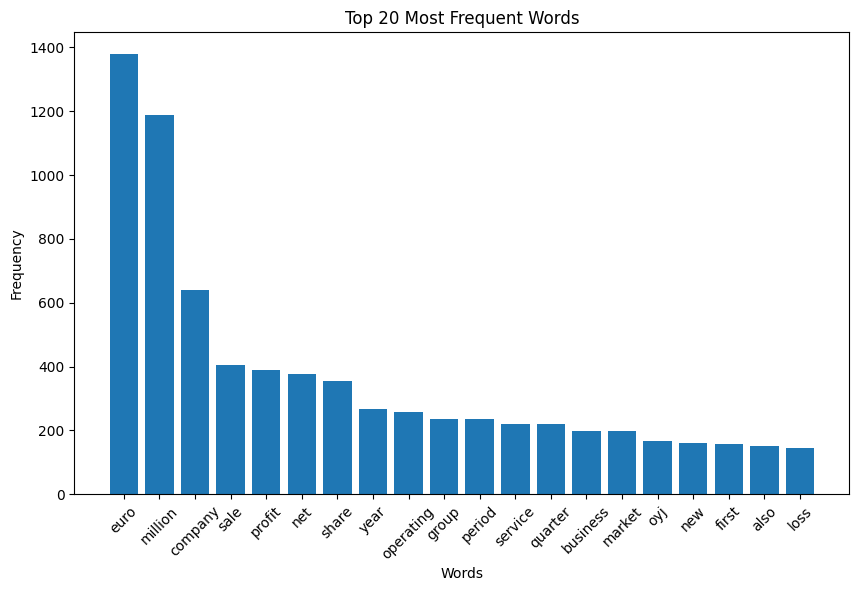

In [23]:
# Plot Most Common Words
words = [word for word, count in common_words]
counts = [count for word, count in common_words]

plt.figure(figsize=(10,6))

plt.bar(words, counts)

plt.title('Top 20 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')

plt.xticks(rotation=45)

plt.show()

# **5. Word Clouds**

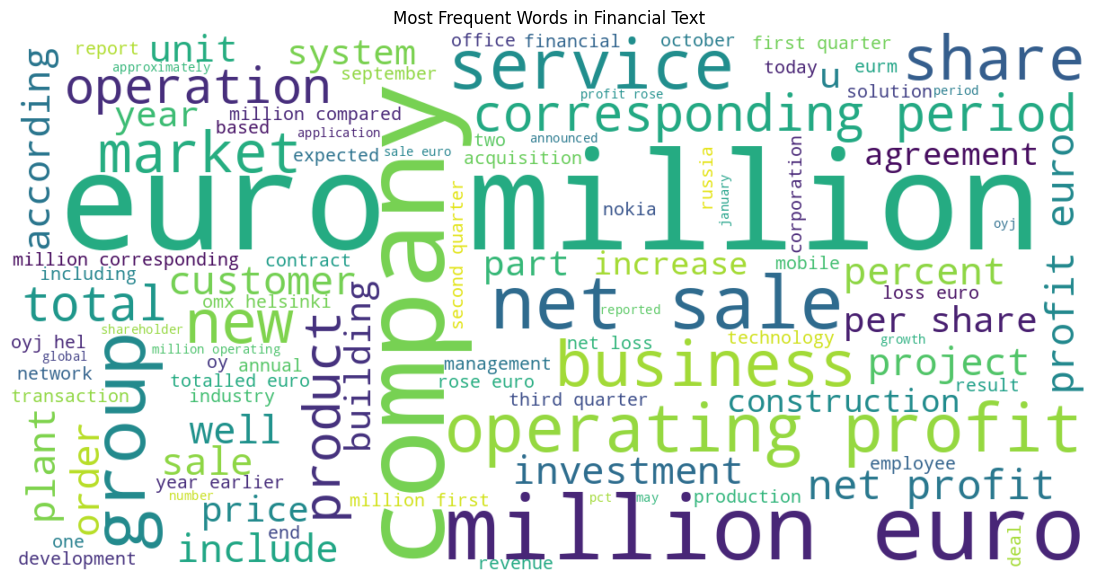

In [24]:
text = ' '.join(df['clean_text'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title('Most Frequent Words in Financial Text')

plt.show()

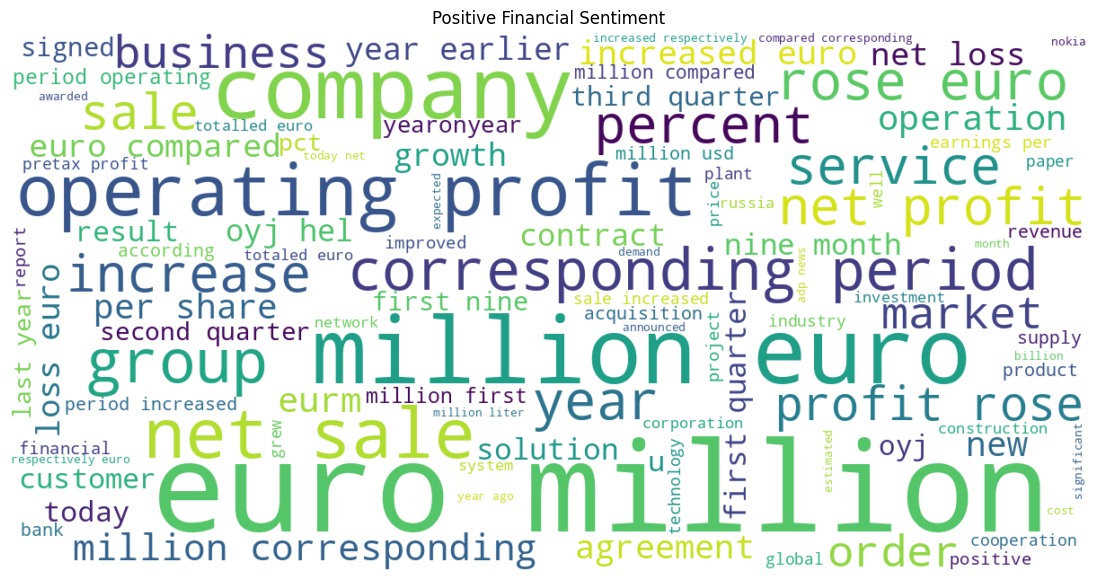

In [25]:
# Positive Word Cloud

positive_text = ' '.join(
    df[df['sentiment'] == 'positive']['clean_text']
)

positive_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(positive_text)

plt.figure(figsize=(15,7))

plt.imshow(
    positive_wordcloud,
    interpolation='bilinear'
)

plt.axis('off')

plt.title('Positive Financial Sentiment')

plt.show()

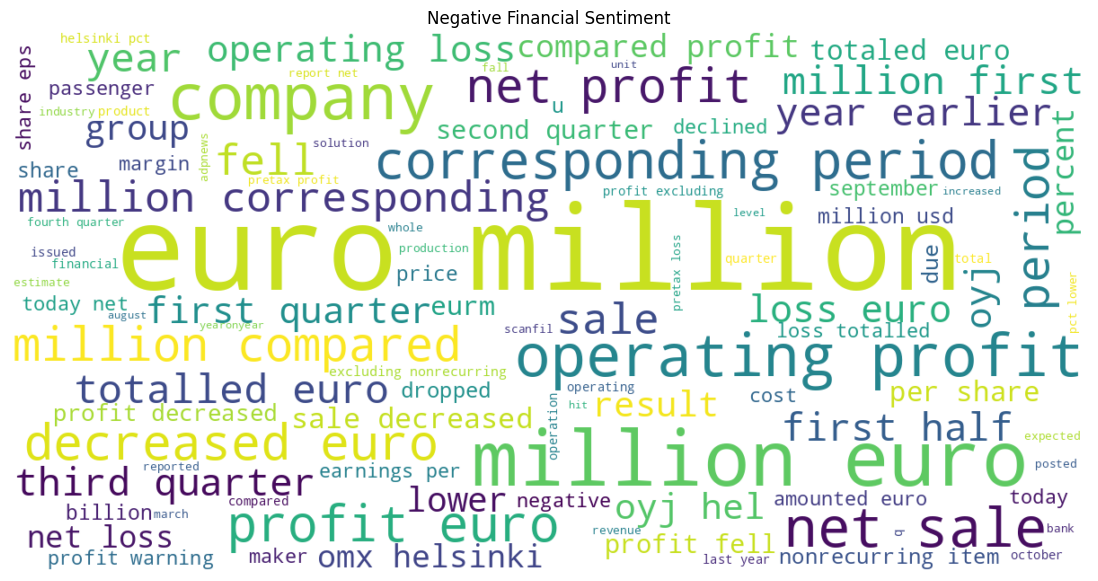

In [26]:
# Negative Word Cloud

negative_text = ' '.join(
    df[df['sentiment'] == 'negative']['clean_text']
)

negative_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(negative_text)

plt.figure(figsize=(15,7))

plt.imshow(
    negative_wordcloud,
    interpolation='bilinear'
)

plt.axis('off')

plt.title('Negative Financial Sentiment')

plt.show()

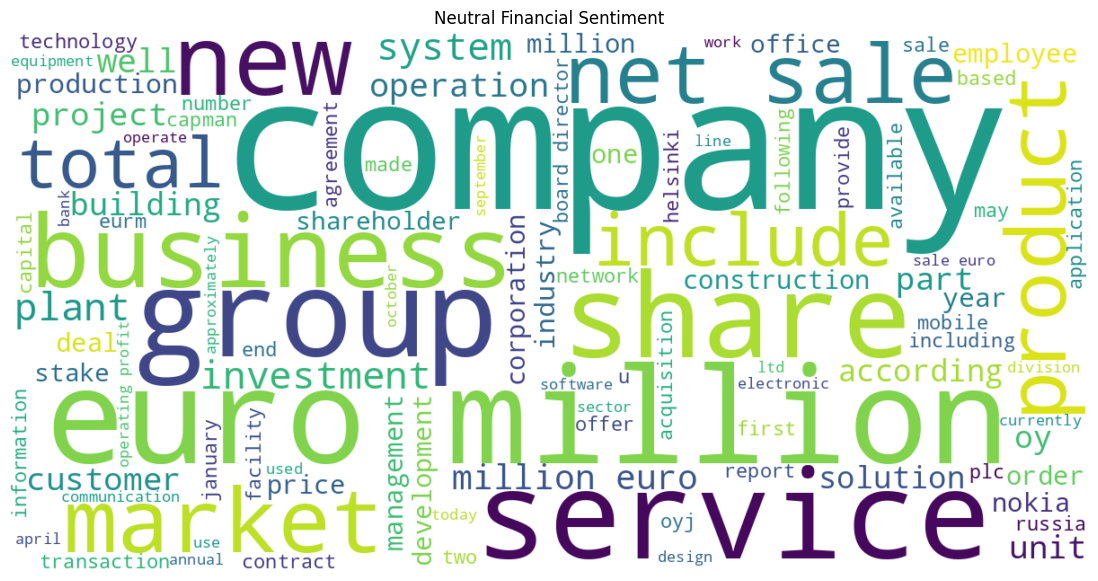

In [27]:
# Neutral Word Cloud

neutral_text = ' '.join(
    df[df['sentiment'] == 'neutral']['clean_text']
)

neutral_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(neutral_text)

plt.figure(figsize=(15,7))

plt.imshow(
    neutral_wordcloud,
    interpolation='bilinear'
)

plt.axis('off')

plt.title('Neutral Financial Sentiment')

plt.show()

# **6. ML**

In [28]:
# Prepare X and y

X = df['clean_text']
y = df['sentiment']


In [29]:
# Encode Sentiment Labels

label_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

y = y.map(label_mapping)

print(y.value_counts())


sentiment
1    2140
2     887
0     420
Name: count, dtype: int64


In [30]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2757
Testing samples: 690


In [32]:
# TF-IDF

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (2757, 5000)
Testing TF-IDF shape: (690, 5000)


# **7. Model 1 — Naive Bayes**

In [33]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb_model.predict(X_test_tfidf)

In [35]:
# Evaluate Naive Bayes

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred, average='weighted')
nb_recall = recall_score(y_test, nb_pred, average='weighted')
nb_f1 = f1_score(y_test, nb_pred, average='weighted')

print("Naive Bayes")
print("-------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Naive Bayes
-------------------
Accuracy : 0.7782608695652173
Precision: 0.7895928034008719
Recall   : 0.7782608695652173
F1 Score : 0.7527631648294445


# **8. Model 2 — Logistic Regression**

In [36]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr_model.predict(X_test_tfidf)

In [37]:
# Evaluate Logistic Regression

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average='weighted')
lr_recall = recall_score(y_test, lr_pred, average='weighted')
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

print("Logistic Regression")
print("-------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression
-------------------
Accuracy : 0.8173913043478261
Precision: 0.8259141016374967
Recall   : 0.8173913043478261
F1 Score : 0.8019994464167179


# **9. Model 3 — Support Vector Machine**

In [38]:
svm_model = LinearSVC()

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm_model.predict(X_test_tfidf)

In [39]:
# Evaluate SVM

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average='weighted')
svm_recall = recall_score(y_test, svm_pred, average='weighted')
svm_f1 = f1_score(y_test, svm_pred, average='weighted')

print("Support Vector Machine")
print("----------------------")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

Support Vector Machine
----------------------
Accuracy : 0.8289855072463768
Precision: 0.8276469834531719
Recall   : 0.8289855072463768
F1 Score : 0.8223143438619873


# 10. Model Comparision

In [40]:
results = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Logistic Regression',
        'SVM'
    ],

    'Accuracy': [
        nb_accuracy,
        lr_accuracy,
        svm_accuracy
    ],

    'Precision': [
        nb_precision,
        lr_precision,
        svm_precision
    ],

    'Recall': [
        nb_recall,
        lr_recall,
        svm_recall
    ],

    'F1 Score': [
        nb_f1,
        lr_f1,
        svm_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.778261,0.789593,0.778261,0.752763
1,Logistic Regression,0.817391,0.825914,0.817391,0.801999
2,SVM,0.828986,0.827647,0.828986,0.822314


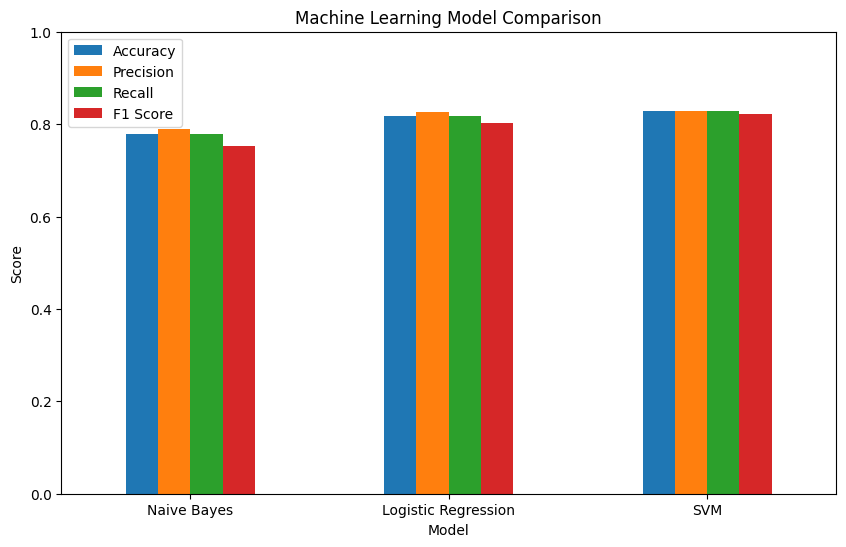

In [41]:
# Visualize Model Comparison

results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Machine Learning Model Comparison')
plt.ylabel('Score')
plt.ylim(0,1)

plt.xticks(rotation=0)

plt.show()

# **11. Find the best Model**

In [42]:
best_model_row = results.loc[
    results['F1 Score'].idxmax()
]

print("Best Model:")
print(best_model_row)

Best Model:
Model             SVM
Accuracy     0.828986
Precision    0.827647
Recall       0.828986
F1 Score     0.822314
Name: 2, dtype: object


# **12. Detailed Classification Report**

In [43]:
print(
    classification_report(
        y_test,
        svm_pred,
        target_names=[
            'Negative',
            'Neutral',
            'Positive'
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.85      0.55      0.67        84
     Neutral       0.84      0.94      0.89       428
    Positive       0.78      0.70      0.74       178

    accuracy                           0.83       690
   macro avg       0.82      0.73      0.76       690
weighted avg       0.83      0.83      0.82       690



# **13. Confusion Matrix**

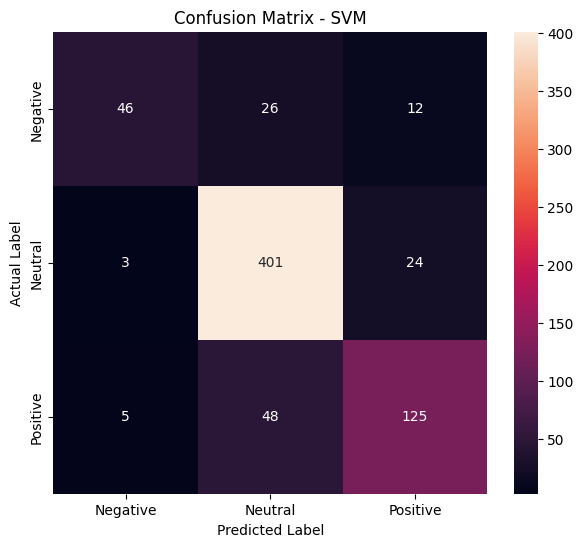

In [44]:
cm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=[
        'Negative',
        'Neutral',
        'Positive'
    ],
    yticklabels=[
        'Negative',
        'Neutral',
        'Positive'
    ]
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - SVM')

plt.show()

# **14. Analyze Misclassified Examples**

In [45]:
test_results = pd.DataFrame({
    'text': X_test,
    'actual': y_test,
    'predicted': svm_pred
})

misclassified = test_results[
    test_results['actual'] != test_results['predicted']
]

print("Number of misclassified examples:", len(misclassified))

display(misclassified.head(20))

Number of misclassified examples: 118


,text,actual,predicted
1289,fiskars yearold global business best known ora...,2,1
3390,company sale three month end march slid euro u...,0,2
2842,sale result capital loss eurm solidium obtaine...,0,1
542,share purchase completed financing also provid...,2,1
1281,china kone provides elevator escalator solutio...,2,1
328,xerox stora enso teamed tailor igen shortrun o...,2,1
1848,according saarioinen managing director ilkka m...,1,2
3406,according company addition normal seasonal flu...,0,1
3087,uncertainty cloud longterm outlook,0,1
1406,previously eb delivered custom solution lg ele...,2,1


In [47]:
# Convert Labels Back to Names

reverse_mapping = {
    0: 'negative',
    1: 'neutral',
    2: 'positive'
}

misclassified['actual'] = misclassified['actual'].map(
    reverse_mapping
)

misclassified['predicted'] = misclassified['predicted'].map(
    reverse_mapping
)

display(misclassified.head(20))

,text,actual,predicted
1289,fiskars yearold global business best known ora...,positive,neutral
3390,company sale three month end march slid euro u...,negative,positive
2842,sale result capital loss eurm solidium obtaine...,negative,neutral
542,share purchase completed financing also provid...,positive,neutral
1281,china kone provides elevator escalator solutio...,positive,neutral
328,xerox stora enso teamed tailor igen shortrun o...,positive,neutral
1848,according saarioinen managing director ilkka m...,neutral,positive
3406,according company addition normal seasonal flu...,negative,neutral
3087,uncertainty cloud longterm outlook,negative,neutral
1406,previously eb delivered custom solution lg ele...,positive,neutral


In [48]:
# Find Important Words for Each Class

feature_names = np.array(
    tfidf.get_feature_names_out()
)

coefficients = svm_model.coef_

In [49]:
classes = svm_model.classes_

for i, class_label in enumerate(classes):

    top_indices = np.argsort(
        coefficients[i]
    )[-20:]

    top_words = feature_names[top_indices]

    print(
        "\nClass:",
        reverse_mapping[class_label]
    )

    print(top_words)


Class: negative
['staff' 'amounted' 'trouble' 'due' 'compared profit' 'decline'
 'operating loss' 'burdened' 'slipped' 'drop' 'negative' 'strike' 'profit'
 'declined' 'weak' 'decreased euro' 'dropped' 'lower' 'fell' 'decreased']

Class: neutral
['value' 'used' 'pension' 'available' 'expected euro' 'employ'
 'profit period' 'come' 'euro net' 'decided' 'headquartered' 'facility'
 'sale million' 'million net' 'part' 'includes' 'approximately' 'include'
 'sale euro' 'million operating']

Class: positive
['favourable' 'euro loss' 'supply' 'expand' 'interested' 'good' 'great'
 'better' 'rise' 'grow' 'improve' 'improved' 'cooperation' 'awarded'
 'positive' 'grew' 'signed' 'increased' 'rose' 'increase']


# **15. Create a Prediction Function**

In [50]:
def predict_sentiment(text):

    cleaned = clean_text(text)

    vectorized = tfidf.transform([cleaned])

    prediction = svm_model.predict(vectorized)[0]

    return reverse_mapping[prediction]

# **16. Test New Financial Sentences**

In [51]:
text1 = "The company's profit increased significantly this year."

text2 = "The company reported a major loss and declining revenue."

text3 = "The company announced its quarterly financial results."

print("Text 1:", predict_sentiment(text1))
print("Text 2:", predict_sentiment(text2))
print("Text 3:", predict_sentiment(text3))

Text 1: positive
Text 2: neutral
Text 3: neutral


In [52]:
# Test Your Own Sentence

new_text = input("Enter a financial sentence: ")

prediction = predict_sentiment(new_text)

print("\nPredicted Sentiment:", prediction)

Enter a financial sentence: The company's profit increased significantly this year.

Predicted Sentiment: positive


# **17. Save the Model**

In [53]:
import joblib

joblib.dump(
    svm_model,
    'financial_sentiment_svm.pkl'
)

joblib.dump(
    tfidf,
    'financial_tfidf.pkl'
)

print("Model and TF-IDF vectorizer saved.")

Model and TF-IDF vectorizer saved.


In [54]:
# Download the Model

from google.colab import files

files.download('financial_sentiment_svm.pkl')
files.download('financial_tfidf.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
# Save Processed Dataset

df.to_csv(
    'financial_sentiment_processed.csv',
    index=False
)

files.download(
    'financial_sentiment_processed.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>